___

> # **1. Motivation.**



<span style="color:red">

* What is your dataset?

* Why did you choose this/these particular dataset(s)?

* What was your goal for the end user's experience?
</span>.

***

> # **2. Basic stats.**

<span style="color:red">

* Write about your choices in data cleaning and preprocessing

* Write a short section that discusses the dataset stats, containing key points/plots from your exploratory data analysis.
</span>.

> ### **2.1.  Dataimport and preprocessing**

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import geopandas as gpd
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
from bokeh.palettes import Category20b # Specific color pallette 

import folium
from folium.plugins import HeatMap
import re

from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, FactorRange, Range1d, LinearAxis, HoverTool
from bokeh.transform import dodge
from bokeh.embed import components
from bokeh.resources import CDN


> **2.1.1 Reading data files**

In [13]:
# Loading shp files
traffic_noise = gpd.read_file("vejstoej_boliger_2022_udv/vejstoej_boliger_2022_udv.shp")
playground= gpd.read_file("legeplads/legeplads.shp")
day_care = gpd.read_file("daginstitutioner/daginstitutionerMPoint.shp")
green_areas= gpd.read_file("park_groent_omr_oversigtskort/park_groent_omr_oversigtskort.shp") 

# Air quality files
df_list_HC = pd.read_html("Aktuel luftkvalitet i Danmark.html")
df_list_jagtvej = pd.read_html("Aktuel luftkvalitet i Danmark jagtvej.html")
df_list_oersted = pd.read_html("Aktuel luftkvalitet i Danmark HCoersted.html")

#Family data
df_family=pd.read_csv("KKFAM1 (1).csv",delimiter=';')
df_pop=pd.read_csv("KKBEF1.csv",delimiter=';')
df_kids=pd.read_csv("KKBEF9.csv",delimiter=';')

# Load data from url
#environmental_zones = gpd.read_file("https://wfs-kbhkort.kk.dk/k101/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=k101:miljozone&outputFormat=json&SRSNAME=EPSG:4326")

> **2.1.2 Cleaning files**

In [14]:
def datetime(name, df_list):
    df= df_list[0]
    df["Målt (starttid)"] = pd.to_datetime(df["Målt (starttid)"], format="%d-%m-%Y %H:%M")
    df = df.sort_values("Målt (starttid)")
    df.set_index("Målt (starttid)", inplace=True)
    

    print("Check for missing values in",name,"\n",df.isna().sum(),"\n")
    return df

df_HC = datetime("HC. Andersen",df_list_HC)
df_jagtvej = datetime("Jagtvej",df_list_jagtvej)
df_oersted = datetime("HC. Oersted",df_list_oersted)


Check for missing values in HC. Andersen 
 CO         0
NO2       43
NOX       58
SO2      102
O3         0
PM10       2
PM2.5     10
dtype: int64 

Check for missing values in Jagtvej 
 NO2    23
NOX    16
dtype: int64 

Check for missing values in HC. Oersted 
 CO       2
NO2    109
NOX    102
O3      11
dtype: int64 



In [15]:
def filldata(df):
    # 1. Create a complete hourly datetime index
    full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
    df = df.reindex(full_index)
    df.index.name = 'timestamp'  # optional, to name the index nicely

    # 2. Create a temporary 'hour' column
    df['hour'] = df.index.hour

    # 3. Group by 'hour', fill missing values with mean of that hour
    df = df.groupby('hour').transform(lambda x: x.fillna(x.mean()))
    print("Check for missing values in",df.isna().sum(),"\n")
    return df


df_HC=filldata(df_HC)
df_jagtvej = filldata(df_jagtvej)
df_oersted = filldata(df_oersted)

Check for missing values in CO       0
NO2      0
NOX      0
SO2      0
O3       0
PM10     0
PM2.5    0
dtype: int64 

Check for missing values in NO2    0
NOX    0
dtype: int64 

Check for missing values in CO     0
NO2    0
NOX    0
O3     0
dtype: int64 



/var/folders/bw/f3ltfwx96zxgwnbblkhmxqvw0000gp/T/ipykernel_6586/3499271419.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
/var/folders/bw/f3ltfwx96zxgwnbblkhmxqvw0000gp/T/ipykernel_6586/3499271419.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
/var/folders/bw/f3ltfwx96zxgwnbblkhmxqvw0000gp/T/ipykernel_6586/3499271419.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


> ## **2.2 Data set stats and summary**

<span style="color:blue">

**NOTER**

* Flere små summaru statistics over alle dataset

</span>

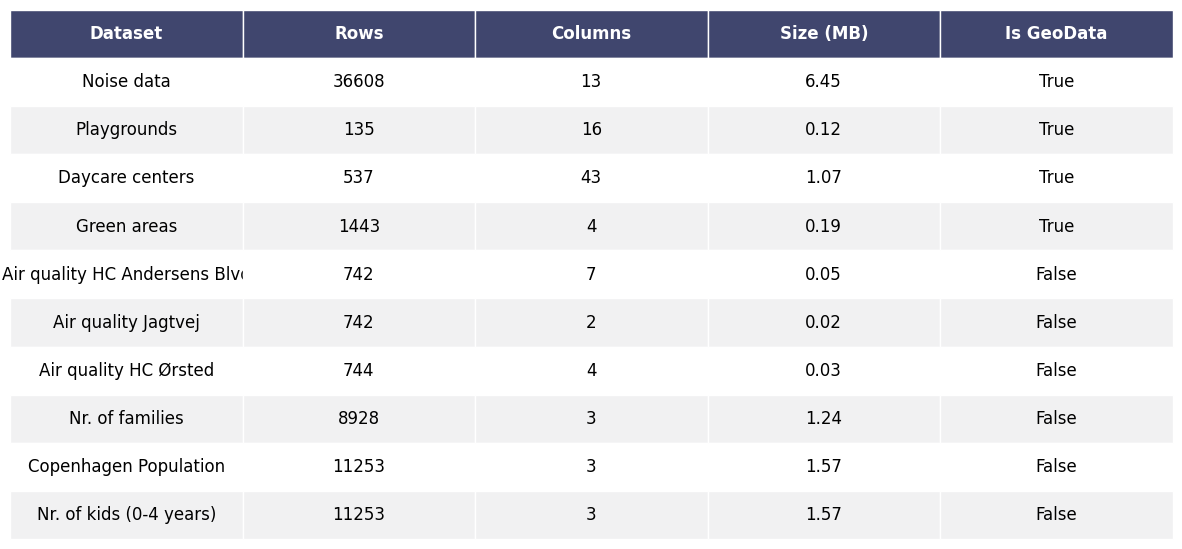


 Basic statistics for: Noise data
                    mean         std           min           max  missing
fid         4.942275e+04    34045.28  1.000000e+00  1.423080e+05        0
fot_id      1.072618e+08  2898382.25  1.064676e+08  1.228060e+08        0
sum_person  1.831000e+01       42.25  0.000000e+00  9.843000e+02        0
max_lden    5.650000e+01        7.29  3.348000e+01  8.112000e+01        0
mean_lden   5.564000e+01        6.78  3.348000e+01  8.112000e+01        0
sum_sbt     1.220000e+00        4.60  0.000000e+00  2.516300e+02        0
58_68_sum_  2.262000e+01       37.74  0.000000e+00  7.642800e+02    25250
over_68_su  2.112000e+01       36.15  0.000000e+00  6.033500e+02    33207
ogc_fid     1.830450e+04    10567.96  1.000000e+00  3.660800e+04        0

 Basic statistics for: Playgrounds
              mean     std  min    max  missing
id          123.39  106.26  1.0  337.0        0
legeplads_   78.14   48.45  1.0  181.0        0
graffitir0   72.36   44.21  1.0  181.0       


 Quantiles for Air quality HC Andersens Blvd:
        CO     NO2     NOX    SO2     O3   PM10  PM2.5
0.25  19.0   76.25  124.25  16.00  473.0  153.0   90.0
0.50  24.0  137.50  231.50  34.24  598.0  241.5  141.0
0.75  30.0  231.75  406.75  53.00  708.0  362.5  246.5



 Quantiles for Air quality Jagtvej:
         NO2     NOX
0.25   68.00   94.25
0.50  121.00  174.00
0.75  205.18  327.88



 Quantiles for Air quality HC Ørsted:
        CO    NO2     NOX      O3
0.25  16.0  36.75   38.00  606.25
0.50  17.0  61.75   70.00  709.00
0.75  20.0  95.96  105.25  797.25


In [ ]:
# Your existing dataset_summary function
def dataset_summary(name, df):
    mem = df.memory_usage(deep=True).sum() / 1024**2  # Convert bytes to MB
    return {
        "Navn": name,
        "Antal rækker": len(df),
        "Antal kolonner": df.shape[1],
        "Størrelse (MB)": round(mem, 2),
        "Geo-data": isinstance(df, gpd.GeoDataFrame)
    }

# Create the summary table
data = [
    dataset_summary("Støjdata", traffic_noise),
    dataset_summary("Legepladser", playground),
    dataset_summary("Daginstitutioner", day_care),
    dataset_summary("Grønne områder", green_areas),
    dataset_summary("Luftkvalitet HC", df_HC),
    dataset_summary("Luftkvalitet Jagtvej", df_jagtvej),
    dataset_summary("Luftkvalitet Ørsted", df_oersted),
    dataset_summary("Antal familier", df_family),
    dataset_summary("Copenhagen Population", df_pop),
    dataset_summary("Antal børn (0-4 år)", df_pop),
]

summary_df = pd.DataFrame(data)

# Translate column names to English
summary_df_english = summary_df.rename(columns={
    "Navn": "Dataset",
    "Antal rækker": "Rows",
    "Antal kolonner": "Columns",
    "Størrelse (MB)": "Size (MB)",
    "Geo-data": "Is GeoData"
})
summary_df_english['Dataset'] = summary_df_english['Dataset'].replace({
    "Støjdata": "Noise data",
    "Legepladser": "Playgrounds",
    "Daginstitutioner": "Daycare centers",
    "Grønne områder": "Green areas",
    "Luftkvalitet HC": "Air quality HC Andersens Blvd",
    "Luftkvalitet Jagtvej": "Air quality Jagtvej",
    "Luftkvalitet Ørsted": "Air quality HC Ørsted",
    "Antal familier":"Nr. of families",
    "Antal børn (0-4 år)":"Nr. of kids (0-4 years)"
})

# Table rendering function
def render_mpl_table(data, col_width=3.0, row_height=0.625, font_size=12,
                     header_color='#40466e', row_colors=['#f1f1f2', 'w'],
                     edge_color='w', bbox=[0, 0, 1, 1], header_columns=0,
                     ax=None, **kwargs):
    if ax is None:
        size = (np.array(data.shape[::-1]) + np.array([0, 1])) * np.array([col_width, row_height])
        fig, ax = plt.subplots(figsize=size)
        ax.axis('off')

    mpl_table = ax.table(cellText=data.values, bbox=bbox, colLabels=data.columns, cellLoc='center', **kwargs)

    mpl_table.auto_set_font_size(False)
    mpl_table.set_fontsize(font_size)

    for k, cell in mpl_table._cells.items():
        cell.set_edgecolor(edge_color)
        if k[0] == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor(header_color)
        else:
            cell.set_facecolor(row_colors[k[0] % len(row_colors)])
    return ax

# Plot summary table
ax = render_mpl_table(summary_df_english, header_columns=0, col_width=3.0)
plt.savefig("summary_table.png", bbox_inches='tight', dpi=300)
plt.show()

# Print basic statistics for each dataset
def print_basic_stats(name, df):
    print(f"\n Basic statistics for: {name}")
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        print("No numeric data available.")
        return
    stats = numeric_df.describe().T
    stats["missing"] = numeric_df.isna().sum()
    print(stats[["mean", "std", "min", "max", "missing"]].round(2))

datasets = [
    ("Noise data", traffic_noise),
    ("Playgrounds", playground),
    ("Daycare centers", day_care),
    ("Green areas", green_areas),
    ("Air quality HC Andersens Blvd", df_HC),
    ("Air quality Jagtvej", df_jagtvej),
    ("Air quality HC Ørsted", df_oersted),
    ("Nr. of families", df_family),
    ("Copenhagen Population", df_pop),
    ("Nr. of kids (0-4 years)", df_pop),
]
def plot_boxplots(datasets):
    """
    Plotly boxplots for a list of datasets.

    Parameters:
    - datasets: list of (name, dataframe) tuples
    """
    for name, df in datasets:
        numeric_df = df.select_dtypes(include=[np.number])
        if numeric_df.empty:
            print(f"Skipping '{name}': No numeric columns.")
            continue

        print(f"\n Quantiles for {name}:")
        q = numeric_df.quantile([0.25, 0.5, 0.75])
        print(q.round(2)) 
        
        fig = go.Figure()

        for col in numeric_df.columns:
            fig.add_trace(go.Box(
                y=numeric_df[col],
                name=col,
                boxmean=True,  # shows mean as a dot
                boxpoints='outliers'  # show outliers
            ))

        fig.update_layout(
            title=f"Interactive Boxplot: {name}",
            yaxis_title="Value",
            xaxis_title="Variables",
            template="plotly_white",
            height=600,
            width=1000
        )
        fig.show()


for name, df in datasets:
    print_basic_stats(name, df)

boxplot_datasets = [
    ("Daycare centers", day_care),
    ("Air quality HC Andersens Blvd", df_HC),
    ("Air quality Jagtvej", df_jagtvej),
    ("Air quality HC Ørsted", df_oersted),
]
plot_boxplots(boxplot_datasets)

import plotly.express as px



Noise data is quite larger than the other dataset. 
The data is aggregated for a lot of the data. 
Describe which files they are

___
> # **3. Data Analysis**

<span style="color:red">

* Describe your data analysis and explain what you've learned about the dataset.

* If relevant, talk about your machine-learning.

</span>.


<span style="color:blue">

**NOTER**

* Polar bar chart over hvornår der er luftforurening
* Gør så man kan scrolle igennem tidsserie dataen
* Man kunne godt lige kigge på sammenghængen mellem den her luftforurening og bilkørsel
* Hvor langt folk har til dagsintitutioner
* Antallet af børnefamilier sammenlignet med indbyggertal samlet

</span>

## Investigation on air pollution 

A Study shows that "in 23 countries and territories across Europe and Central Asia died from causes linked to air pollution in 2021, according to a new policy brief published today by UNICEF. Deaths linked to air pollution across the region accounted for 1 in 5 of all deaths of children under one."
https://www.unicef.org/tajikistan/press-releases/1-5-infant-deaths-europe-and-central-asia-linked-air-pollution-unicef

In [ ]:
def plot_luftforurening_horizontal(df1, df2, df3):
    fig = make_subplots(
        rows=3, 
        cols=1, 
        subplot_titles=["H. C. Andersens Boulevard", "Jagtvej", "H. C. Ørsted Instituttet"],
        shared_xaxes=True,  # Share the x-axis across all subplots
        vertical_spacing=0.02  # Reduce vertical spacing between plots
    )

    # Define a consistent color mapping for each column
    color_mapping = {
        "CO": "blue",
        "NO2": Category20b[20][3],
        "NOX": Category20b[20][3+4],
        "SO2": "purple",
        "O3": "orange",
        "PM10": Category20b[20][3+8],
        "PM2.5": Category20b[20][3+12]
    }

    # Track which columns have already been added to the legend
    added_to_legend = set()

    for row, df in enumerate([df1, df2, df3], start=1):
        numeric_cols = df.select_dtypes(include='number').columns
        for column in numeric_cols:
            show_legend = column not in added_to_legend
            if show_legend:
                added_to_legend.add(column)
            fig.add_trace(
                go.Scatter(
                    x=df.index, 
                    y=df[column], 
                    mode='lines', 
                    name=column if show_legend else None,  # Add to legend only once
                    showlegend=show_legend,  # Control legend visibility
                    line=dict(color=color_mapping.get(column, "gray"))
                ),
                row=row, col=1
            )

    # Update the legend to be horizontal
    fig.update_layout(
        legend=dict(
            orientation="h"
        )
    )

    fig.update_layout(
        title="Timeseries of Air Quality Measurements",
        #add text size
        title_font=dict(size=25),
        height=1000,
        width=1000,
        template="plotly_white",
        font=dict(family="Times New Roman"),  # Set font to Times New Roman
        legend=dict(
            y=-0.05,  # Move the legend below the plot
            xanchor="center",
            x=0.5
        )
    )

    # Add y-axis labels for each subplot
    fig.update_yaxes(title_text="Concentration [μg/m³]", row=1, col=1)
    fig.update_yaxes(title_text="Concentration [μg/m³]", row=2, col=1)
    fig.update_yaxes(title_text="Concentration [μg/m³]", row=3, col=1)

    fig.show()

plot_luftforurening_horizontal(df_HC, df_jagtvej, df_oersted)


The timeseries plots show that the concentration of different air polluters vary significantly thoughout March 2025. It also shows that only NOX and NO2 is measured at Jagtvej, and that the finer particle (PM2.5 and PM10) as well as SO2 is only measured at HC Andersens Boulevard. Furthermore, there are missing data at Jagtvej between March 10th to 13th. 

### Polar bar chart function

In order to investigate how big the concentrations are during an average day, a polar bar chart is created. 


In [ ]:
def create_polar_bar_chart(df, row, col, column, title, marker_color, marker_line_color):
    hourly_counts = df.groupby(df.index.hour)[column].mean()
    values = hourly_counts.reindex(range(24), fill_value=0)
    angles = np.linspace(0, 360, 24, endpoint=False)
    fig.add_trace(go.Barpolar(r=values, theta=angles+7, width=[15] * 24, marker_color=marker_color, marker_line_color=marker_line_color, marker_line_width=0.5, opacity=1, name=title), row=row, col=col)
    fig.update_polars(radialaxis=dict(visible=True, range=[0, values.max() + 50], tickangle=90, tickfont=dict(size=14, family='Times New Roman black')), angularaxis=dict(tickmode='array', tickvals=angles, ticktext=[f"{h}:00" for h in range(24)], direction="clockwise", rotation=90), row=row, col=col)


In order to get the hourly average of a typical day, the resample functions is used for each measuring point. 

In [ ]:
df_HC_hourly_average = df_HC.resample('H').mean()
df_jagtvej_hourly_average = df_jagtvej.resample('H').mean()
df_ørsted_hourly_average = df_oersted.resample('H').mean()

The polar bar charts shows how much the average emmission measured pr hour vary during a day of 24 hours. The emissions of NOX and NO2 is compared by location, as these are the only measurements that overlap across the locations. 

In [ ]:

fig = make_subplots(rows=1, cols=3, subplot_titles=['H. C. Andersens Boulevard', 'Jagtvej', 'H. C. Ørsted Instituttet'], specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]], horizontal_spacing=0.1)
fig.update_layout(title_text="NOX emissions [μg/m³]", title_x=0.5, title_font=dict(size=20, family="Times New Roman"))
create_polar_bar_chart(df_HC_hourly_average, 1, 1, 'NOX', 'H. C. Andersens Boulevard',Category20b[20][3+4], Category20b[20][0+4]); create_polar_bar_chart(df_ørsted_hourly_average, 1, 2, 'NOX', 'H. C. Ørsted Instituttet', Category20b[20][3+4], Category20b[20][0+4]); create_polar_bar_chart(df_jagtvej_hourly_average, 1, 3, 'NOX', 'jagtvej',Category20b[20][3+4], Category20b[20][0+4])
fig.update_layout(showlegend=False, font=dict(family="Times New Roman"), annotations=[dict(text='H. C. Andersens Boulevard', x=0.15, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16), font_color='black'), dict(text='H. C. Ørsted Instituttet', x=0.5, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16)), dict(text='Jagtvej', x=0.85, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16))], polar=dict(domain=dict(x=[0.0, 0.3], y=[0.0, 1.0])), polar2=dict(domain=dict(x=[0.35, 0.65], y=[0.0, 1.0])), polar3=dict(domain=dict(x=[0.7, 1.0], y=[0.0, 1.0])))
fig.show()

fig = make_subplots(rows=1, cols=3, subplot_titles=['HC Andersens Blvd', 'Jagtvej', 'H. C. Ørsted Instituttet'], specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]], horizontal_spacing=0.1)
fig.update_layout(title_text="NO2 emissions [μg/m³]", title_x=0.5, title_font=dict(size=20, family="Times New Roman"))
create_polar_bar_chart(df_HC_hourly_average, 1, 1, 'NO2', 'H. C. Andersens Boulevard', Category20b[20][3], Category20b[20][0]); create_polar_bar_chart(df_ørsted_hourly_average, 1, 2, 'NO2', 'H. C. Ørsted Instituttet', Category20b[20][3], Category20b[20][0]); create_polar_bar_chart(df_jagtvej_hourly_average, 1, 3, 'NO2', 'jagtvej', Category20b[20][3], Category20b[20][0])
fig.update_layout(showlegend=False, font=dict(family="Times New Roman"), annotations=[dict(text='H. C. Andersens Boulevard', x=0.15, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16), font_color='black'), dict(text='H. C. Ørsted Instituttet', x=0.5, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16)), dict(text='Jagtvej', x=0.86, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16))], polar=dict(domain=dict(x=[0.0, 0.3], y=[0.0, 1.0])), polar2=dict(domain=dict(x=[0.35, 0.65], y=[0.0, 1.0])), polar3=dict(domain=dict(x=[0.7, 1.0], y=[0.0, 1.0])))
fig.show()


NOx is a combination of the two gasses NO and NO2, where the NO2 is most harmful, and is emitted into the air from burning fuels, which primarily stems from cars in urban areas. The department for Environment, Food and Rural affairs describes that NO2 "can cause inflammation of the airways and may increase susceptibility to respiratory infections" https://www.gov.uk/government/statistics/air-quality-statistics/ntrogen-dioxide , which is especially critical for childrens lung development and can create asthma. Furthermore, air pollution also affects pregnancies by low birth weight and pre term births. https://www.eea.europa.eu/en/newsroom/news/air-pollution-levels-across-europe. 


The polar bar chart clearly shows that the concentration is highest in the morning between 6-9, which likely is because this is the time very people are driving to work. The limit set by the EU states that NO2 emissions shold not exceed 200 in a 1 hour average https://environment.ec.europa.eu/topics/air/air-quality/eu-air-quality-standards_en which is exceeded in both Jagtvej and H. C Andersen s bourlevard during this time period and also in hour 20 at H. C. Andersens Boulevard. 

Furthermore, the middle of the day show very low concentrations, and increases again at hour 17-18, however, this is below the EU limit. 

The finer particles (PM2.5 and PM10) is similarly plotted, however this is only measures at the H. C. Andersens Boulevard measurement station. This pollutant are much more damaging, and can cause strokes, cancer and respiratory deasises,  https://www.eea.europa.eu/en/newsroom/news/air-pollution-levels-across-europe, and the PM2.5 is so small that it penetrates deep inside the lings and into the bloodstreams https://www.unicef.org/tajikistan/press-releases/1-5-infant-deaths-europe-and-central-asia-linked-air-pollution-unicef


In [ ]:

fig = make_subplots(rows=1, cols=2, subplot_titles=['PM2.5', 'PM10'], specs=[[{'type': 'polar'}, {'type': 'polar'}]], horizontal_spacing=0.1)
fig.update_layout(title_text="H. C. Andersens Boulevard", title_x=0.3, title_font=dict(size=20, family="Times New Roman"))
df_HC_hourly_average = df_HC.resample('H').mean()
create_polar_bar_chart(df_HC_hourly_average, 1, 1, 'PM2.5', 'H. C. Andersens Boulevard', Category20b[20][3+8+4], Category20b[20][0+8+4]); create_polar_bar_chart(df_HC_hourly_average, 1, 2, 'PM10', 'HC Andersens Blvd', Category20b[20][3+8], Category20b[20][0+8])
fig.update_layout(showlegend=False, font=dict(family="Times New Roman"), annotations=[dict(text='PM2.5 emissions [μg/m³]', x=0.15, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16), font_color='black'), dict(text='PM10 emissions [μg/m³]', x=0.51, y=1.05, xref='paper', yref='paper', showarrow=False, font=dict(size=16))], polar=dict(domain=dict(x=[0.0, 0.3], y=[0.0, 1.0])), polar2=dict(domain=dict(x=[0.35, 0.65], y=[0.0, 1.0])))
fig.show()

The EU directive states that the yearly average of 20 and 40 µg/m3 should not be exceeded for PM2.5 and PM10, respectively. https://environment.ec.europa.eu/topics/air/air-quality/eu-air-quality-standards_en. However, for the month of March this average is exceeded ibn all hours of the day, indicating that this could be highly problematic, especially for children who grow up there, because it will have long term health issues. 





The municipality of Copenhagen has also made initiatives to improve the air quality in the city. One of these initiatives is the establishment of environmental zones implemented in 2020, which are areas where certain vehicles are restricted or banned to reduce air pollution by having a particle filter. [https://miljoezoner.dk/om-mz/om-miljozoner/] . Below the environmental zone of Copenhagen is highligtes, and the specific measurement locations are also pinpointed [https://envs.au.dk/om-instituttet-1/faglige-omraader/luftforurening-udledninger-og-effekter/overvaagningsprogrammet/maalestationer/maalingerpaastationerne/koebenhavn] , where it is possible to hover over to see which specific location it is. 



In [ ]:
ørsted_location = [55.701047, 12.561766]
jagtvej_location = [55.698333, 12.553333]
HCanders_location = [55.700277, 12.561388]

def plot_environmentalZones(data):
    center = [55.6761, 12.5683]  # Latitude, Longitude of Copenhagen
    m = folium.Map(location=center, zoom_start=12)  # Create a folium map centered at Copenhagen
    folium.GeoJson(
        data,
        name="Miljozone",
        style_function=lambda x: {
            'fillColor': Category20b[20][3],  # Change the fill color to blue
            'color': Category20b[20][0],     # Change the border color to black
            'weight': 1,          # Set the border weight
            'fillOpacity': 0.5    # Set the fill opacity
        }
    ).add_to(m)  # Add the environmental zone (miljozone) to the map
    # Add the Ørsted location as a marker
    folium.Marker(
        location=ørsted_location,
        popup="Ørsted measuring station",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    folium.Marker(
    location=jagtvej_location,
    popup="Jagtvej measuring station",
    icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    folium.Marker(
    location=HCanders_location,
    popup="H. C. Andersens Boulevar measuring station",
    icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    
    return m  # Return the map object to display it in the notebook

plot_environmentalZones(environmental_zones)

In [ ]:
import plotly.express as px

def traffic_noise_plot_plotly(df):
    # Ensure GeoDataFrame is in WGS84
    df = df.to_crs(epsg=4326)

    fig = px.choropleth_mapbox(
        df,
        geojson=df.geometry,
        locations=df.index,
        color='mean_lden',
        color_continuous_scale=[
            [0, "mistyrose"],    # Very low noise
            [0.5, "salmon"],     # Medium noise
            [0.75, "red"],       # Higher noise
            [0.9, "darkred"],    # Very high noise
            [1.0, "black"]       # Extreme noise
        ],
        range_color=(df['mean_lden'].min(), df['mean_lden'].max()),
        mapbox_style="carto-positron",
        center={"lat": 55.6761, "lon": 12.5683},
        zoom=11,
        opacity=0.6,
        labels={'mean_lden': 'Noise Level (dB)'},
        height=700
    )

    # Remove ugly polygon edges
    fig.update_traces(marker_line_width=0)

    # --- Make hover text clean ---
    fig.update_traces(
        hovertemplate="<b>Noise Level:</b> %{z:.1f} dB<extra></extra>"
    )

    fig.update_layout(
        margin={"r":0,"t":40,"l":0,"b":0},
        title="Traffic Noise Levels in Copenhagen",
    )

    fig.show()
    fig.write_html("traffic_noise_map.html")

traffic_noise_plot_plotly(traffic_noise)


In [ ]:
import geopandas as gpd
import plotly.graph_objects as go

# --- Prepare green areas ---
green_areas_kbh = green_areas[green_areas['kommune'] == 'København']
green_areas_kbh = green_areas_kbh.to_crs(epsg=4326)  # Ensure it's in WGS84
green_areas_kbh['geometry'] = green_areas_kbh['geometry'].simplify(0.0001, preserve_topology=True)

# Export real GeoJSON
import json
green_geojson = json.loads(green_areas_kbh.to_json())

# --- Prepare playgrounds ---
playground['lon'] = playground.geometry.apply(lambda geom: geom.geoms[0].x)
playground['lat'] = playground.geometry.apply(lambda geom: geom.geoms[0].y)

# --- Create figure ---
fig = go.Figure()

# Add playground points
fig.add_trace(go.Scattermapbox(
    lat=playground['lat'],
    lon=playground['lon'],
    mode='markers',
    marker=dict(size=10, color='purple'),
    text=playground['navn'],
    hoverinfo='text'
))

# Set up Mapbox with a GeoJSON layer for green areas
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        zoom=11,
        center={"lat": 55.6761, "lon": 12.5683},
        layers=[
            {
                "sourcetype": "geojson",
                "source": green_geojson,
                "type": "fill",
                "color": "darkgreen",
                "opacity": 0.8,
                "below": "traces"   # <-- key line here
            }
        ]
    ),
    height=800,
    margin={"r":0,"t":40,"l":0,"b":0},
    title="Playgrounds and Green Areas in Copenhagen"
)

fig.show()


In [ ]:
# Only keep rows where TID contains 'K1'
df_family = df_family[df_family['TID'].str.contains('K1', na=False)]


# Clean TID: keep only the year before 'K'
df_family['TID'] = df_family['TID'].str.split('K').str[0]
df_family['TID'] = pd.to_numeric(df_family['TID'], errors='coerce')

# Make sure INDHOLD is numeric
df_family['INDHOLD'] = pd.to_numeric(df_family['INDHOLD'], errors='coerce')

# Clean OMRKK
df_family['OMRKK'] = df_family['OMRKK'].astype(str).str.split('-').str[0]

# Define the list of areas you want to keep
areas = [
    "Østerbro", "Indre By", "Nørrebro", "Vesterbro", "Valby", "Vanløse",
    "Brønshøj-Husum", "Bispebjerg", "Amager Vest", "Amager Øst",
    "Christianshavn", "Kgs. Enghave"
]
df_family_areas=df_family.copy()
# For each row, set OMRKK to the matching area name (if any)
def match_area(text):
    for area in areas:
        if area in text:
            return area
    return None

df_family_areas['OMRKK'] = df_family_areas['OMRKK'].apply(match_area)

# Keep only rows that matched
df_fam = df_family_areas.dropna(subset=['OMRKK', 'TID', 'INDHOLD'])

# Group by the cleaned OMRKK and TID
df_grouped = df_fam.groupby(['OMRKK', 'TID'], as_index=False)['INDHOLD'].sum()

# Create a plotly figure
fig = go.Figure()

# Add a trace for each OMRKK
for omrkk, group in df_grouped.groupby('OMRKK'):
    fig.add_trace(go.Scatter(
        x=group['TID'],
        y=group['INDHOLD'],
        mode='lines+markers',
        name=str(omrkk)
    ))

# Customize layout
fig.update_layout(
    title='Evolution of nr. of families in 1998-2025',
    xaxis_title='Year',
    yaxis_title='Nr. of families',
    legend_title='Areas of Copenhagen',
    hovermode='x unified'
)

# Show the plot
fig.show()


In [ ]:
# Calculate the peak (maximum INDHOLD) and the last INDHOLD
first_last_peak = df_grouped.sort_values('TID').groupby('OMRKK').agg(
    peak_indhold=('INDHOLD', 'max'),
    last_indhold=('INDHOLD', 'last')
)

# Calculate difference between last and peak

first_last_peak['decrease_from_peak'] = first_last_peak['last_indhold'] - first_last_peak['peak_indhold']

# Find the area with the biggest increase overall (still based on first to last)
# (Optional, based on previous method)
first_last = df_grouped.sort_values('TID').groupby('OMRKK').agg(
    first_indhold=('INDHOLD', 'first'),
    last_indhold=('INDHOLD', 'last')
)
first_last['change'] = first_last['last_indhold'] - first_last['first_indhold']
biggest_increase = first_last['change'].idxmax()
increase_amount = first_last.loc[biggest_increase, 'change']

print(f"The area with the biggest increase (first to last) is **{biggest_increase}** with an increase of {increase_amount:.2f} INDHOLD units.")

# Find areas where last value is lower than peak
decreased_from_peak = first_last_peak[first_last_peak['decrease_from_peak'] < 0]

if not decreased_from_peak.empty:
    print("\nAreas that had a decrease from their peak:")
    for area, row in decreased_from_peak.iterrows():
        print(f"- {area}: decreased by {abs(row['decrease_from_peak']):} INDHOLD units from their peak")
else:
    print("\nNo areas decreased from their peak.")


In [ ]:
# Now filter for København i alt
df_kbh_family = df_family[df_family['OMRKK'].str.contains("København i alt", na=False)]

# Group if needed
df_kbh_familiy_grouped = df_kbh_family.groupby('TID', as_index=False)['INDHOLD'].sum()

# Only keep rows where TID contains 'K1'
df_pop = df_pop[df_pop['TID'].str.contains('K1', na=False)]
# Clean TID: keep only the year before 'K'
df_pop['TID'] = df_pop['TID'].str.split('K').str[0]
df_pop['TID'] = pd.to_numeric(df_pop['TID'], errors='coerce')

# Make sure INDHOLD is numeric
df_pop['INDHOLD'] = pd.to_numeric(df_pop['INDHOLD'], errors='coerce')

# Clean OMRKK
df_pop['OMRKK'] = df_pop['OMRKK'].astype(str).str.split('-').str[0]

# Now filter for København i alt
df_kbh_pop = df_pop[df_pop['OMRKK'].str.contains("København i alt", na=False)]

# Group if needed
df_kbh_pop_grouped = df_kbh_pop.groupby('TID', as_index=False)['INDHOLD'].sum()
df_kbh_pop_grouped = df_kbh_pop_grouped.rename(columns={'INDHOLD': 'Population'})

# Merge the two datasets on 'TID' (year)
merged_df = pd.merge(df_kbh_familiy_grouped, df_kbh_pop_grouped, on='TID', how='inner')

# Calculate percentage
merged_df['Percentage_Families'] = (merged_df['INDHOLD'] / merged_df['Population']) * 100


In [ ]:

fig = go.Figure()

# First y-axis: Number of families
fig.add_trace(go.Scatter(
    x=merged_df['TID'],
    y=merged_df['INDHOLD'],
    mode='lines+markers',
    name='Number of Families',
    yaxis='y1'
))
# Second y-axis: Percentage of families
fig.add_trace(go.Scatter(
    x=merged_df['TID'],
    y=merged_df['Percentage_Families'],
    mode='lines+markers',
    name='% of Families in Population',
    yaxis='y2'
))

# Layout with two y-axes
fig.update_layout(
    title='Families in Copenhagen: Total Number and Share of Population (1998–2025)',
    xaxis=dict(title='Year'),
    yaxis=dict(
        title='Number of Families',
        side='left'
    ),
    yaxis2=dict(
        title='Percentage (%)',
        overlaying='y',
        side='right'
    ),
    legend_title='Metric',
    hovermode='x unified'
)

fig.show()

This plot compares the number of families in Copenhagen with percentage of families in respect to the total number of population in copenhagen. There have been a significant increase of families since 2005 to 2025. There have however been a slight decrease in families compared to the total population

In [ ]:

# Only keep K1
df_kids['INDHOLD'] = pd.to_numeric(df_kids['INDHOLD'], errors='coerce')
df_kids['OMRKK'] = df_kids['OMRKK'].astype(str).str.split('-').str[0]
# Define areas
areas = [
    "Østerbro", "Indre By", "Nørrebro", "Vesterbro", "Valby", "Vanløse",
    "Brønshøj-Husum", "Bispebjerg", "Amager Vest", "Amager Øst",
    "Christianshavn", "Kgs. Enghave"
]

# Match areas
def match_area(text):
    for area in areas:
        if area in text:
            return area
    return None

df_kids['OMRKK'] = df_kids['OMRKK'].apply(match_area)




# Combine Vesterbro + Kgs. Enghave
df_kids['OMRKK'] = df_kids['OMRKK'].replace({'Vesterbro': 'Vesterbro-Kongens Enghave',
                                                 'Kgs. Enghave': 'Vesterbro-Kongens Enghave'})

# Now group by area and year
df_kids_grouped = df_kids.dropna(subset=['OMRKK', 'TID', 'INDHOLD'])
#Ganger med procent børn i instution
df_kids_grouped = df_kids_grouped.groupby(['OMRKK', 'TID'], as_index=False)['INDHOLD'].sum()

# Get latest year (e.g., 2025) for analysis
latest_year = df_kids_grouped['TID'].max()
df_kids_latest = df_kids_grouped[df_kids_grouped['TID'] == latest_year][['OMRKK', 'INDHOLD']]

# Step 1: Rename columns for merging (if not already done)
df_kids_latest = df_kids_latest.rename(columns={'OMRKK': 'City district', 'INDHOLD': 'Number of kids'})
bydel_counts = day_care['bydel'].value_counts().reset_index()
bydel_counts.columns = ['City district', 'Number of institutions']

# Step 2: Total kids and institutions in Copenhagen
total_kids = df_kids_latest['Number of kids'].sum()
total_institutions = bydel_counts['Number of institutions'].sum()

# Step 3: Average capacity per institution
avg_capacity_per_inst = total_kids / total_institutions

# Step 4: Merge and estimate spots
merged = pd.merge(bydel_counts, df_kids_latest, on='City district', how='inner')
merged['Estimated spots'] = merged['Number of institutions'] * avg_capacity_per_inst

# Step 5: Coverage ratio
merged['Coverage ratio'] = merged['Estimated spots'] / merged['Number of kids']

# Optional: make it % for readability
merged['Coverage (%)'] = (merged['Coverage ratio'] * 100).round(1)

In [ ]:
# --- Step 1: Count playgrounds per district ---
playground_counts = playground['bydel'].value_counts().reset_index()
playground_counts.columns = ['City district', 'Number of playgrounds']

# --- Step 2: Prepare kids data ---
# (Assuming df_kids_latest has already been cleaned)
df_kids_latest = df_kids_latest.rename(columns={'OMRKK': 'City district', 'INDHOLD': 'Number of kids'})  # if not already

# --- Step 3: Merge ---
merged_playgrounds = pd.merge(playground_counts, df_kids_latest, on='City district', how='inner')

# --- Step 4: Calculate ratio ---
merged_playgrounds['Playgrounds per 1000 kids'] = (merged_playgrounds['Number of playgrounds'] / merged_playgrounds['Number of kids']) * 1000

# Optional: Round nicely
merged_playgrounds['Playgrounds per 1000 kids'] = merged_playgrounds['Playgrounds per 1000 kids'].round(2)

# --- Prepare data ---
daycare = merged[['City district', 'Coverage (%)']].copy()
playgrounds = merged_playgrounds[['City district', 'Playgrounds per 1000 kids']].copy()

combined = pd.merge(daycare, playgrounds, on='City district', how='inner')

districts = list(combined['City district'])

data = {
    'districts': districts,
    'Coverage (%)': combined['Coverage (%)'].round(1).tolist(),
    'Playgrounds per 1000 kids': combined['Playgrounds per 1000 kids'].round(2).tolist()
}

source = ColumnDataSource(data=data)

# --- Create figure ---
p = figure(
    x_range=FactorRange(*districts),
    height=600,
    title="Daycare Coverage vs Playgrounds per 1000 Kids",
    toolbar_location="above",
    tools="pan,box_zoom,reset,save"
)

# --- Add bars ---

# Left y-axis (Coverage %)
p.vbar(
    x=dodge('districts', -0.15, range=p.x_range),
    top='Coverage (%)',
    width=0.25,
    source=source,
    color="#718dbf",
    legend_label="Coverage (%)",
    muted_alpha=0.1,
    muted=True,
    name="Coverage"
)

# Add extra right y-axis for Playgrounds
p.extra_y_ranges = {"playgrounds_axis": Range1d(start=0, end=max(data['Playgrounds per 1000 kids']) * 1.5)}
p.add_layout(LinearAxis(y_range_name="playgrounds_axis", axis_label="Playgrounds per 1000 kids"), 'right')

# Right y-axis (Playgrounds per 1000 kids)
p.vbar(
    x=dodge('districts', 0.15, range=p.x_range),
    top='Playgrounds per 1000 kids',
    width=0.25,
    source=source,
    color="#e84d60",
    legend_label="Playgrounds per 1000 kids",
    muted_alpha=0.1,
    muted=True,
    line_color="white",
    y_range_name="playgrounds_axis",
    name="Playgrounds"
)

# --- Add hover tool ---
hover = HoverTool(tooltips=[
    ("District", "@districts"),
    ("Coverage (%)", "@{Coverage (%)}%"),
    ("Playgrounds per 1000 kids", "@{Playgrounds per 1000 kids}")
])

p.add_tools(hover)

# --- Styling ---
p.xgrid.grid_line_color = None
p.y_range.start = 0
p.x_range.range_padding = 0.1
p.xaxis.major_label_orientation = 1
p.yaxis.axis_label = "Coverage (%)"
p.legend.location = "top_left"
p.legend.orientation = "vertical"
p.legend.click_policy = "mute"

# --- Output ---
output_file("daycare_vs_playgrounds_dual_axis.html")
show(p)

# Save standalone components
script, div = components(p)
with open("daycare_vs_playgrounds_components.html", "w") as f:
    f.write(f"""
    <!DOCTYPE html>
    <html>
    <head>
    {CDN.render()}
    </head>
    <body>
    {div}
    {script}
    </body>
    </html>
    """)


---

> # **4. Genre**




<span style="color:red">

* Which genre of data story did you use?

* Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?

* Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?

</span>.

___
> # **5. Visualizations**


<span style="color:red">

* Explain the visualizations you've chosen.

* Why are they right for the story you want to tell?

</span>.

___
> # **6. Discussion.**

<span style="color:red">

* Think critically about your creation

* What went well?,

* What is still missing? What could be improved?, Why?

</span>.

___
> # **7. Contributions.**

<span style="color:red">

* You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain). It is not OK simply to write "All group members contributed equally".
</span>.



Data collection together

Noa did day care and population

Marie main responsible fpr pollution



___
> # **8. Make sure that you use references when they're needed and follow academic standards.**